# Make figs

In [1]:
import numpy as np
import scipy.linalg
from scipy.optimize import minimize
from scipy.optimize import minimize_scalar
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.colorbar as colorbars
import matplotlib.gridspec as gridspec
#import pandas as pd
import datetime
import os
import time
import pathlib
import pickle
import sys
import string
#import uncertainties
#from uncertainties import ufloat

import ising_model as ising

plt.rcParams["font.family"] = "Helvetica"
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['svg.fonttype'] = 'path'

cm = plt.get_cmap('Paired')
blue = cm(1)
green = cm(3)
red = cm(5)
orange = cm(7)
purple = cm(9)

## Load data

In [2]:
# instance
n_spin = 25

## Average acceptance probability

(5, 10, 100000)
[0.04604329 0.04599228 0.0465948  0.04626332 0.04730569 0.04606068
 0.04592387 0.04650789 0.04641725 0.04651977]


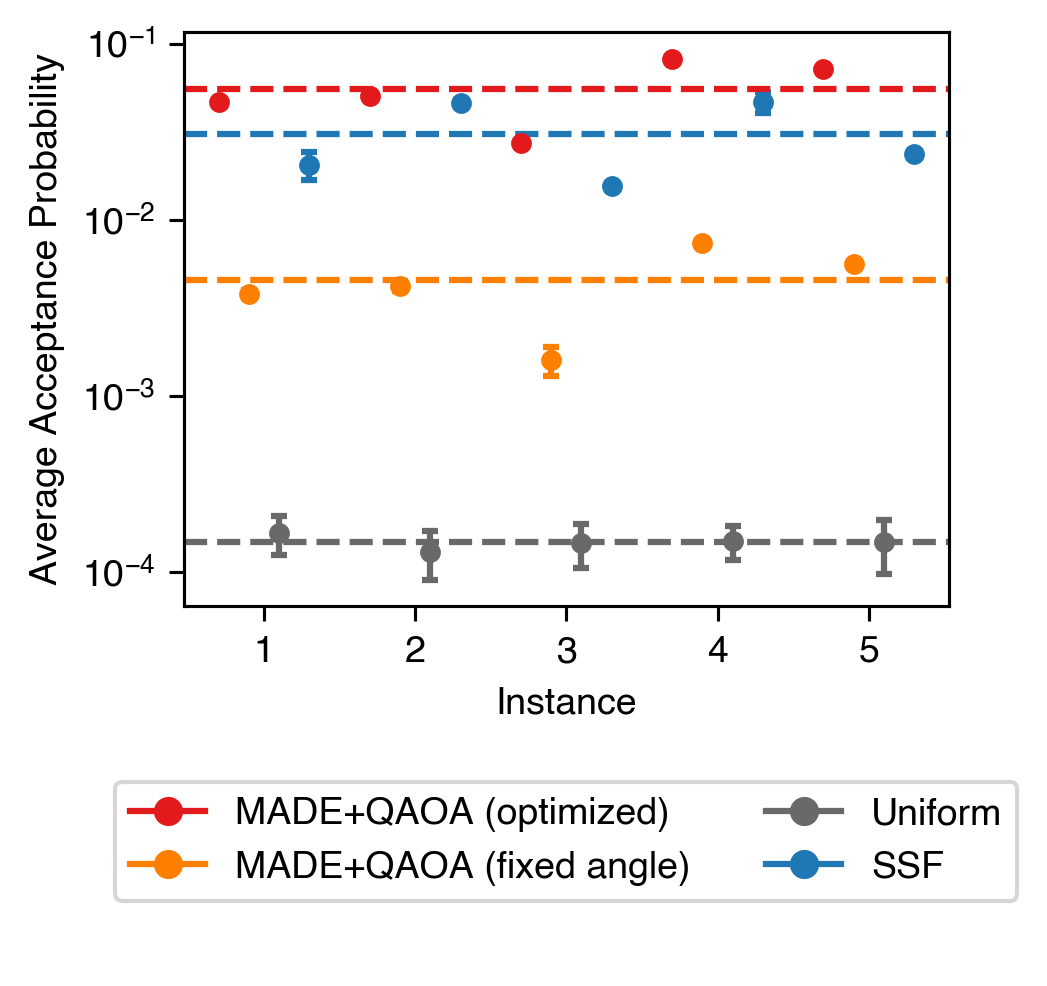

In [3]:
# import
n_instance = 5
for i in range(n_instance):
	if i == 0:
		opt_qaoa_made_acceptance_history = np.load('result/mcmc_simulation/{0}_sites_result_0{1}/acceptance_history/opt_qaoa_made_acceptance_history.npy'.format(n_spin, i+1), allow_pickle=True)[np.newaxis]
		fix_qaoa_made_acceptance_history = np.load('result/mcmc_simulation/{0}_sites_result_0{1}/acceptance_history/fix_qaoa_made_acceptance_history.npy'.format(n_spin, i+1), allow_pickle=True)[np.newaxis]
		uniform_acceptance_history = np.load('result/mcmc_simulation/{0}_sites_result_0{1}/acceptance_history/uniform_acceptance_history.npy'.format(n_spin, i+1), allow_pickle=True)[np.newaxis]
		ssf_acceptance_history = np.load('result/mcmc_simulation/{0}_sites_result_0{1}/acceptance_history/ssf_acceptance_history.npy'.format(n_spin, i+1), allow_pickle=True)[np.newaxis]
	else:
		opt_qaoa_made_acceptance_history = np.concatenate([opt_qaoa_made_acceptance_history, np.load('result/mcmc_simulation/{0}_sites_result_0{1}/acceptance_history/opt_qaoa_made_acceptance_history.npy'.format(n_spin, i+1), allow_pickle=True)[np.newaxis]])
		fix_qaoa_made_acceptance_history = np.concatenate([fix_qaoa_made_acceptance_history, np.load('result/mcmc_simulation/{0}_sites_result_0{1}/acceptance_history/fix_qaoa_made_acceptance_history.npy'.format(n_spin, i+1), allow_pickle=True)[np.newaxis]])
		uniform_acceptance_history = np.concatenate([uniform_acceptance_history, np.load('result/mcmc_simulation/{0}_sites_result_0{1}/acceptance_history/uniform_acceptance_history.npy'.format(n_spin, i+1), allow_pickle=True)[np.newaxis]])
		ssf_acceptance_history = np.concatenate([ssf_acceptance_history, np.load('result/mcmc_simulation/{0}_sites_result_0{1}/acceptance_history/ssf_acceptance_history.npy'.format(n_spin, i+1), allow_pickle=True)[np.newaxis]])

print(opt_qaoa_made_acceptance_history.shape)

# accept rate
opt_accept_prob = np.average(opt_qaoa_made_acceptance_history, axis=2)
fix_accept_prob = np.average(fix_qaoa_made_acceptance_history, axis=2)
uni_accept_prob = np.average(uniform_acceptance_history, axis=2)
ssf_accept_prob = np.average(ssf_acceptance_history, axis=2)
print(opt_accept_prob[0])

capsize = 2
markersize = 4
elinewidth = 1.5
capthick = 1.5
linewidth = 1.5
spines = 0.75
fontsize = 9

fig0, ax0 = plt.subplots(2,1, figsize=(3.29,4), gridspec_kw=dict(height_ratios=[5,2], hspace=0.3), dpi=300)
for i in range(n_instance):
	ax0[0].errorbar(i + 0.7, np.average(opt_accept_prob[i]), np.std(opt_accept_prob[i]), label='QAOA+MADE(opt)', linestyle='none', marker='o', markersize=markersize, capsize=capsize, capthick=capthick, elinewidth=elinewidth, color=red)
	ax0[0].errorbar(i + 0.9, np.average(fix_accept_prob[i]), np.std(fix_accept_prob[i]), label='QAOA+MADE(fix)', linestyle='none', marker='o', markersize=markersize, capsize=capsize, capthick=capthick, elinewidth=elinewidth, color=orange)
	ax0[0].errorbar(i + 1.1, np.average(uni_accept_prob[i]), np.std(uni_accept_prob[i]), label='Uniform', linestyle='none', marker='o', markersize=markersize, capsize=capsize, capthick=capthick, elinewidth=elinewidth, color='dimgrey')
	ax0[0].errorbar(i + 1.3, np.average(ssf_accept_prob[i]), np.std(ssf_accept_prob[i]), label='SSF', linestyle='none', marker='o', markersize=markersize, capsize=capsize, capthick=capthick, elinewidth=elinewidth, color=blue)

ax0[0].axhline(np.average(np.average(opt_accept_prob, axis=1), axis=0), color=red, linestyle='--', linewidth=linewidth)
ax0[0].axhline(np.average(np.average(fix_accept_prob, axis=1), axis=0), color=orange, linestyle='--', linewidth=linewidth)
ax0[0].axhline(np.average(np.average(uni_accept_prob, axis=1), axis=0), color='dimgrey', linestyle='--', linewidth=linewidth)
ax0[0].axhline(np.average(np.average(ssf_accept_prob, axis=1), axis=0), color=blue, linestyle='--', linewidth=linewidth)
 
#ax0[0].set_axisbelow(True) #gridを背面にする
ax0[0].spines["top"].set_linewidth(spines)
ax0[0].spines["left"].set_linewidth(spines)
ax0[0].spines["bottom"].set_linewidth(spines)
ax0[0].spines["right"].set_linewidth(spines)

ax0[0].set_yscale('log')
ax0[0].set_xlabel('Instance', fontsize=fontsize)
ax0[0].set_ylabel(r'Average Acceptance Probability', fontsize=fontsize)
ax0[0].tick_params(labelsize=fontsize)
ax0[0].tick_params(which='major', width=spines)
ax0[0].minorticks_off()

ax0[-1].plot([], [], marker='o', color=red, label='MADE+QAOA (optimized)', linestyle=None)
ax0[-1].plot([], [], marker='o', color=orange, label='MADE+QAOA (fixed angle)', linestyle=None)
ax0[-1].plot([], [], marker='o', color='dimgrey', label='Uniform', linestyle=None)
ax0[-1].plot([], [], marker='o', color=blue, label='SSF', linestyle=None)

for spine in ax0[-1].spines.values():
    spine.set_visible(False)
ax0[-1].axes.get_xaxis().set_visible(False)
ax0[-1].axes.get_yaxis().set_visible(False)
ax0[-1].legend(fontsize=fontsize, bbox_to_anchor=(0.5,0.5), loc='center', ncol=2, frameon=True)

## acceptance

(5, 10, 100000)
[0.04592 0.0459  0.04656 0.04646 0.04781 0.0459  0.04581 0.0463  0.04684
 0.04663]


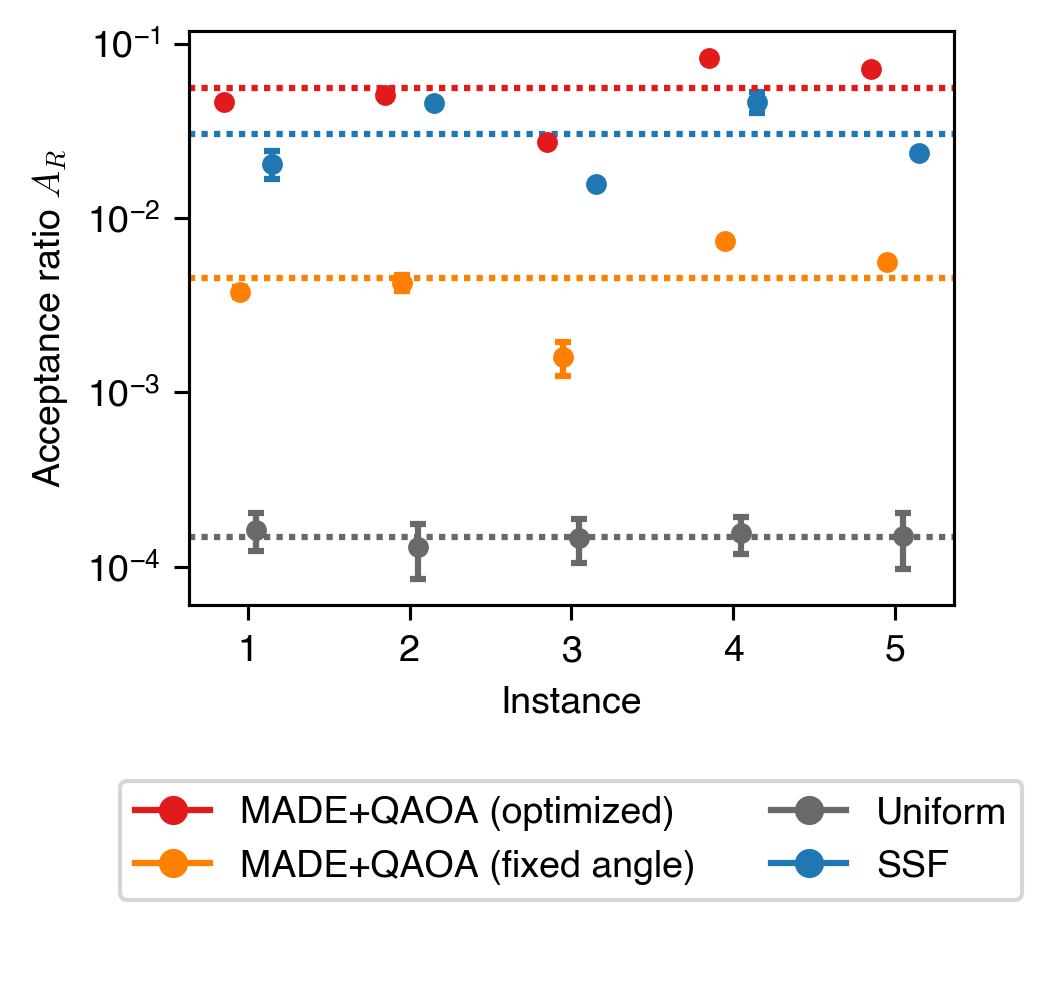

In [14]:
# import
n_instance = 5
for i in range(n_instance):
	if i == 0:
		opt_qaoa_made_update_log = np.load('result/mcmc_simulation/{0}_sites_result_0{1}/update_log/opt_qaoa_made_update_log.npy'.format(n_spin, i+1), allow_pickle=True)[np.newaxis]
		fix_qaoa_made_update_log = np.load('result/mcmc_simulation/{0}_sites_result_0{1}/update_log/fix_qaoa_made_update_log.npy'.format(n_spin, i+1), allow_pickle=True)[np.newaxis]
		uniform_update_log = np.load('result/mcmc_simulation/{0}_sites_result_0{1}/update_log/uniform_update_log.npy'.format(n_spin, i+1), allow_pickle=True)[np.newaxis]
		ssf_update_log = np.load('result/mcmc_simulation/{0}_sites_result_0{1}/update_log/ssf_update_log.npy'.format(n_spin, i+1), allow_pickle=True)[np.newaxis]
	else:
		opt_qaoa_made_update_log = np.concatenate([opt_qaoa_made_update_log, np.load('result/mcmc_simulation/{0}_sites_result_0{1}/update_log/opt_qaoa_made_update_log.npy'.format(n_spin, i+1), allow_pickle=True)[np.newaxis]])
		fix_qaoa_made_update_log = np.concatenate([fix_qaoa_made_update_log, np.load('result/mcmc_simulation/{0}_sites_result_0{1}/update_log/fix_qaoa_made_update_log.npy'.format(n_spin, i+1), allow_pickle=True)[np.newaxis]])
		uniform_update_log = np.concatenate([uniform_update_log, np.load('result/mcmc_simulation/{0}_sites_result_0{1}/update_log/uniform_update_log.npy'.format(n_spin, i+1), allow_pickle=True)[np.newaxis]])
		ssf_update_log = np.concatenate([ssf_update_log, np.load('result/mcmc_simulation/{0}_sites_result_0{1}/update_log/ssf_update_log.npy'.format(n_spin, i+1), allow_pickle=True)[np.newaxis]])

print(opt_qaoa_made_update_log.shape)

# accept rate
opt_accept_rate = np.count_nonzero(opt_qaoa_made_update_log, axis=2) / opt_qaoa_made_update_log.shape[2]
fix_accept_rate = np.count_nonzero(fix_qaoa_made_update_log, axis=2) / fix_qaoa_made_update_log.shape[2]
uni_accept_rate = np.count_nonzero(uniform_update_log, axis=2) / uniform_update_log.shape[2]
ssf_accept_rate = np.count_nonzero(ssf_update_log, axis=2) / ssf_update_log.shape[2]
print(opt_accept_rate[0])

capsize = 2
markersize = 4
elinewidth = 1.5
capthick = 1.5
linewidth = 1.5
spines = 0.75
fontsize = 9
linestyle = (0, (1, 1)) # 'densely dotted'

fig1, ax1 = plt.subplots(2,1, figsize=(3.29,4), gridspec_kw=dict(height_ratios=[5,2], hspace=0.3), dpi=300)
for i in range(n_instance):
	ax1[0].errorbar(i + 0.85, np.average(opt_accept_rate[i]), np.std(opt_accept_rate[i]), label='QAOA+MADE(opt)', linestyle='none', marker='o', markersize=markersize, capsize=capsize, capthick=capthick, elinewidth=elinewidth, color=red)
	ax1[0].errorbar(i + 0.95, np.average(fix_accept_rate[i]), np.std(fix_accept_rate[i]), label='QAOA+MADE(fix)', linestyle='none', marker='o', markersize=markersize, capsize=capsize, capthick=capthick, elinewidth=elinewidth, color=orange)
	ax1[0].errorbar(i + 1.05, np.average(uni_accept_rate[i]), np.std(uni_accept_rate[i]), label='Uniform', linestyle='none', marker='o', markersize=markersize, capsize=capsize, capthick=capthick, elinewidth=elinewidth, color='dimgrey')
	ax1[0].errorbar(i + 1.15, np.average(ssf_accept_rate[i]), np.std(ssf_accept_rate[i]), label='SSF', linestyle='none', marker='o', markersize=markersize, capsize=capsize, capthick=capthick, elinewidth=elinewidth, color=blue)

ax1[0].axhline(np.average(np.average(opt_accept_rate, axis=1), axis=0), color=red, linestyle=linestyle, linewidth=linewidth)
ax1[0].axhline(np.average(np.average(fix_accept_rate, axis=1), axis=0), color=orange, linestyle=linestyle, linewidth=linewidth)
ax1[0].axhline(np.average(np.average(uni_accept_rate, axis=1), axis=0), color='dimgrey', linestyle=linestyle, linewidth=linewidth)
ax1[0].axhline(np.average(np.average(ssf_accept_rate, axis=1), axis=0), color=blue, linestyle=linestyle, linewidth=linewidth)
 
#ax1[0].set_axisbelow(True) #gridを背面にする
ax1[0].spines["top"].set_linewidth(spines)
ax1[0].spines["left"].set_linewidth(spines)
ax1[0].spines["bottom"].set_linewidth(spines)
ax1[0].spines["right"].set_linewidth(spines)

ax1[0].set_yscale('log')
ax1[0].set_xlabel('Instance', fontsize=fontsize)
ax1[0].set_ylabel(r'Acceptance ratio $A_R$', fontsize=fontsize)
ax1[0].tick_params(labelsize=fontsize)
ax1[0].tick_params(which='major', width=spines)
ax1[0].minorticks_off()

ax1[-1].plot([], [], marker='o', color=red, label='MADE+QAOA (optimized)', linestyle=None)
ax1[-1].plot([], [], marker='o', color=orange, label='MADE+QAOA (fixed angle)', linestyle=None)
ax1[-1].plot([], [], marker='o', color='dimgrey', label='Uniform', linestyle=None)
ax1[-1].plot([], [], marker='o', color=blue, label='SSF', linestyle=None)

for spine in ax1[-1].spines.values():
    spine.set_visible(False)
ax1[-1].axes.get_xaxis().set_visible(False)
ax1[-1].axes.get_yaxis().set_visible(False)
ax1[-1].legend(fontsize=fontsize, bbox_to_anchor=(0.5,0.5), loc='center', ncol=2, frameon=True)
fig1.savefig("figure/acceptance_rate.svg", dpi=300, bbox_inches='tight')

## Effective Sample Size

In [5]:
# import
n_instance = 5
for i in range(n_instance):
	if i == 0:
		opt_qaoa_made_sample = np.load('result/mcmc_simulation/{0}_sites_result_0{1}/sample/opt_qaoa_made_sample.npy'.format(n_spin, i+1), allow_pickle=True)[np.newaxis]
		fix_qaoa_made_sample = np.load('result/mcmc_simulation/{0}_sites_result_0{1}/sample/fix_qaoa_made_sample.npy'.format(n_spin, i+1), allow_pickle=True)[np.newaxis]
		uniform_sample = np.load('result/mcmc_simulation/{0}_sites_result_0{1}/sample/uniform_sample.npy'.format(n_spin, i+1), allow_pickle=True)[np.newaxis]
		ssf_sample = np.load('result/mcmc_simulation/{0}_sites_result_0{1}/sample/ssf_sample.npy'.format(n_spin, i+1), allow_pickle=True)[np.newaxis]
	else:
		opt_qaoa_made_sample = np.concatenate([opt_qaoa_made_sample, np.load('result/mcmc_simulation/{0}_sites_result_0{1}/sample/opt_qaoa_made_sample.npy'.format(n_spin, i+1), allow_pickle=True)[np.newaxis]])
		fix_qaoa_made_sample = np.concatenate([fix_qaoa_made_sample, np.load('result/mcmc_simulation/{0}_sites_result_0{1}/sample/fix_qaoa_made_sample.npy'.format(n_spin, i+1), allow_pickle=True)[np.newaxis]])
		uniform_sample = np.concatenate([uniform_sample, np.load('result/mcmc_simulation/{0}_sites_result_0{1}/sample/uniform_sample.npy'.format(n_spin, i+1), allow_pickle=True)[np.newaxis]])
		ssf_sample = np.concatenate([ssf_sample, np.load('result/mcmc_simulation/{0}_sites_result_0{1}/sample/ssf_sample.npy'.format(n_spin, i+1), allow_pickle=True)[np.newaxis]])

print(opt_qaoa_made_sample.shape)

(5, 10, 100001, 25)


## magnetization

In [6]:
idx = 1

# import instance sets
fname_in = pathlib.Path('data').joinpath('{0}_sites_instance_0{1}.pickle'.format(n_spin, idx))
with open(str(fname_in), 'rb') as f:
	instance = pickle.load(f)
 
# import data
opt_qaoa_made_sample = np.load('result/mcmc_simulation/{0}_sites_result_0{1}/sample/opt_qaoa_made_sample.npy'.format(n_spin, idx), allow_pickle=True)
fix_qaoa_made_sample = np.load('result/mcmc_simulation/{0}_sites_result_0{1}/sample/fix_qaoa_made_sample.npy'.format(n_spin, idx), allow_pickle=True)
uniform_sample = np.load('result/mcmc_simulation/{0}_sites_result_0{1}/sample/uniform_sample.npy'.format(n_spin, idx), allow_pickle=True)
ssf_sample = np.load('result/mcmc_simulation/{0}_sites_result_0{1}/sample/ssf_sample.npy'.format(n_spin, idx), allow_pickle=True)

normalize = np.tile(np.arange(1, opt_qaoa_made_sample.shape[1]+1), (opt_qaoa_made_sample.shape[0], 1))
opt_mag = np.cumsum(np.average(opt_qaoa_made_sample, axis=2), axis=1) / normalize
fix_mag = np.cumsum(np.average(fix_qaoa_made_sample, axis=2), axis=1) / normalize
uniform_mag = np.cumsum(np.average(uniform_sample, axis=2), axis=1) / normalize
ssf_mag = np.cumsum(np.average(ssf_sample, axis=2), axis=1) / normalize

opt_qaoa_made_mag_mean = np.average(opt_mag**2, axis=0)
fix_qaoa_made_mag_mean = np.average(fix_mag**2, axis=0)
uniform_mag_mean = np.average(uniform_mag**2, axis=0)
ssf_mag_mean = np.average(ssf_mag**2, axis=0)

opt_qaoa_made_mag_std = np.std(opt_mag**2, axis=0)
fix_qaoa_made_mag_std = np.std(fix_mag**2, axis=0)
uniform_mag_std = np.std(uniform_mag**2, axis=0)
ssf_mag_std = np.std(ssf_mag**2, axis=0)

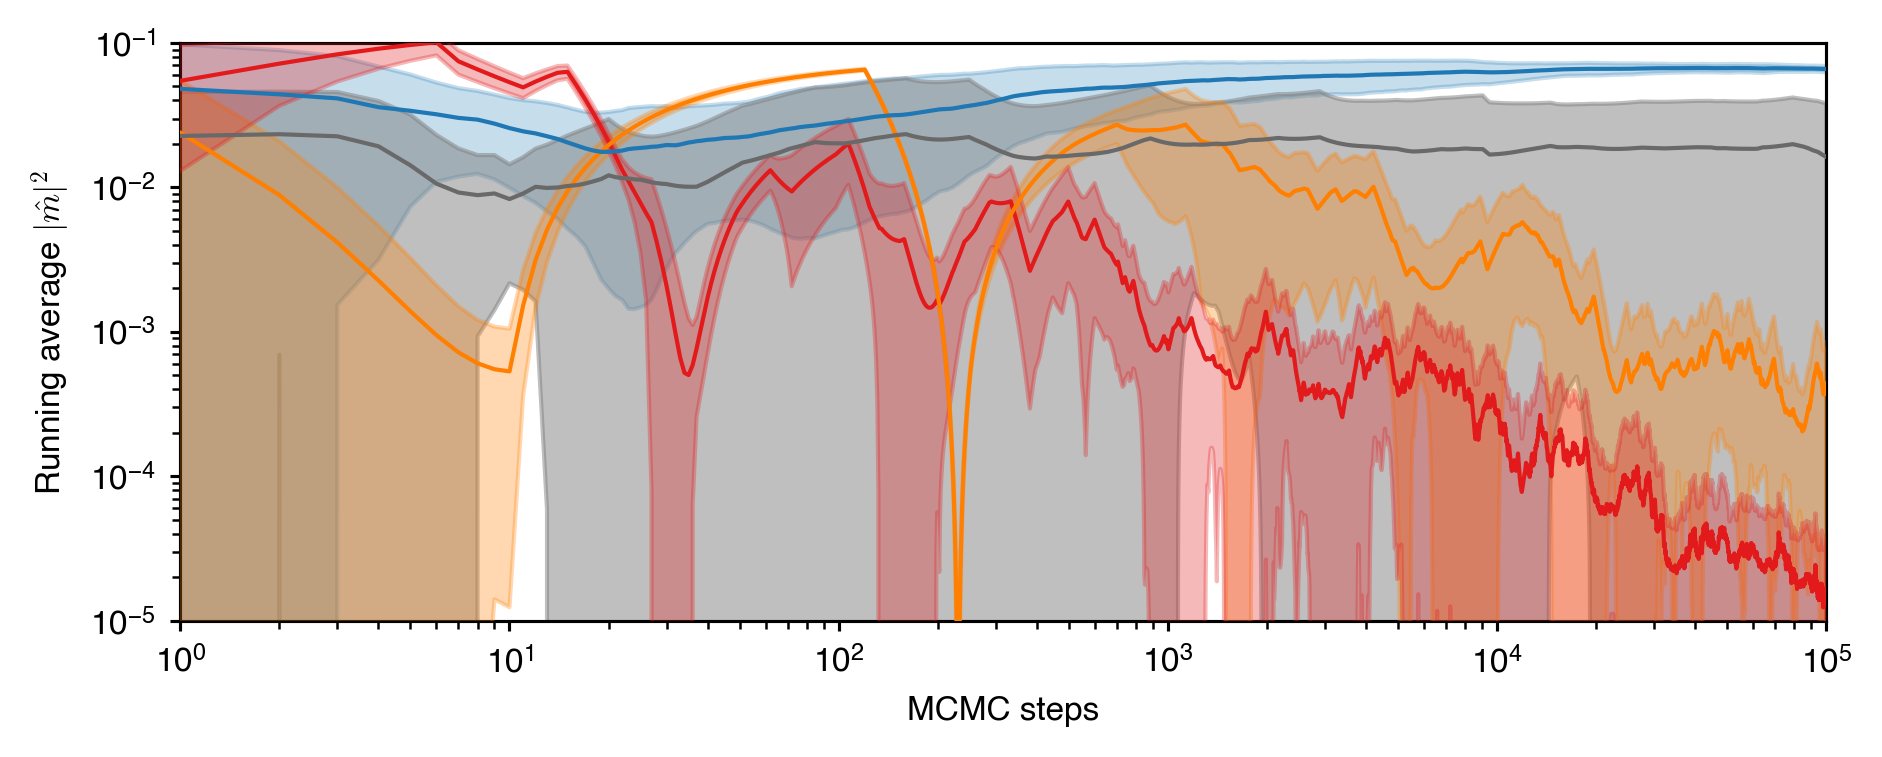

In [7]:
n_step = opt_qaoa_made_sample.shape[1] - 1

capsize = 2
markersize = 3
elinewidth = 1
capthick = 1
linewidth = 1
spines = 0.75
fontsize = 8

fig2, ax2 = plt.subplots(figsize=(7.08,2.5), dpi=300)

ax2.spines["top"].set_linewidth(spines)
ax2.spines["left"].set_linewidth(spines)
ax2.spines["bottom"].set_linewidth(spines)
ax2.spines["right"].set_linewidth(spines)

ax2.plot(np.arange(n_step+1), opt_qaoa_made_mag_mean, color=red, linewidth=linewidth, label='MADE+QAOA (optimized)', zorder=5)
ax2.fill_between(np.arange(n_step+1), opt_qaoa_made_mag_mean+opt_qaoa_made_mag_std, opt_qaoa_made_mag_mean-opt_qaoa_made_mag_std, color=red, alpha=0.3, zorder=4)

ax2.plot(np.arange(n_step+1), fix_qaoa_made_mag_mean, color=orange, linewidth=linewidth, label='MADE+QAOA (fixed angle)', zorder=5)
ax2.fill_between(np.arange(n_step+1), fix_qaoa_made_mag_mean+fix_qaoa_made_mag_std, fix_qaoa_made_mag_mean-fix_qaoa_made_mag_std, color=orange, alpha=0.3, zorder=3)

ax2.plot(np.arange(n_step+1), uniform_mag_mean, color='dimgrey', linewidth=linewidth, label='Uniform', zorder=5)
ax2.fill_between(np.arange(n_step+1), uniform_mag_mean+uniform_mag_std, uniform_mag_mean-uniform_mag_std, color='grey', alpha=0.5, zorder=2)

ax2.plot(np.arange(n_step+1), ssf_mag_mean, color=blue, linewidth=linewidth, label='SSF', zorder=5)
ax2.fill_between(np.arange(n_step+1), ssf_mag_mean+ssf_mag_std, ssf_mag_mean-ssf_mag_std, color=blue, alpha=0.25, zorder=1)

ax2.axhline(0.0, color='black', linestyle='--', linewidth=linewidth)
#ax2.axhline(true_val, color='black', linestyle='--', linewidth=linewidth)

ax2.set_xlim(1, n_step)
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_ylim(1e-5,1e-1)
ax2.set_xlabel('MCMC steps', fontsize=fontsize)
ax2.set_ylabel(r'Running average ${|\hat{m}|}^2$', fontsize=fontsize)
ax2.tick_params(width=spines, labelsize=fontsize, length=2.5, labelbottom=True)
ax2.tick_params(axis="x", which='major', width=spines)

## Effective Sample Size

In [8]:
# 磁化の二乗に対する自己相関
def mcmc_sqrt_magnetization_autocorrelation(spin_history, lag):
	sqrt_mag_history = np.average(spin_history, axis=2)**2
	sqrt_mag_mean = np.tile(np.average(sqrt_mag_history, axis=1).reshape((sqrt_mag_history.shape[0],1)), (1,spin_history.shape[1]))
	sqrt_mag_acf = np.zeros((spin_history.shape[0], lag))
    
	for j in range(lag):
		if j == 0:
			sqrt_mag_acf[:,j] = 1.0
		else:
			n = spin_history.shape[1] - j
			sqrt_mag_acf[:,j] = np.average((sqrt_mag_history[:,:n] - sqrt_mag_mean[:,:n]) * (sqrt_mag_history[:,-n:] - sqrt_mag_mean[:,:n]), axis=1)
			sqrt_mag_acf[:,j] /= np.sqrt(np.average((sqrt_mag_history[:,:n] - sqrt_mag_mean[:,:n])**2, axis=1) * np.average((sqrt_mag_history[:,-n:] - sqrt_mag_mean[:,:n])**2, axis=1))
	
	return sqrt_mag_acf

lag = 50000
mag_acf_history_opt_made = mcmc_sqrt_magnetization_autocorrelation(opt_qaoa_made_sample, lag)
mag_acf_history_fix_made = mcmc_sqrt_magnetization_autocorrelation(fix_qaoa_made_sample, lag)
mag_acf_history_uni = mcmc_sqrt_magnetization_autocorrelation(uniform_sample, lag)
mag_acf_history_ssf = mcmc_sqrt_magnetization_autocorrelation(ssf_sample, lag)
print(mag_acf_history_opt_made.shape)

(10, 50000)


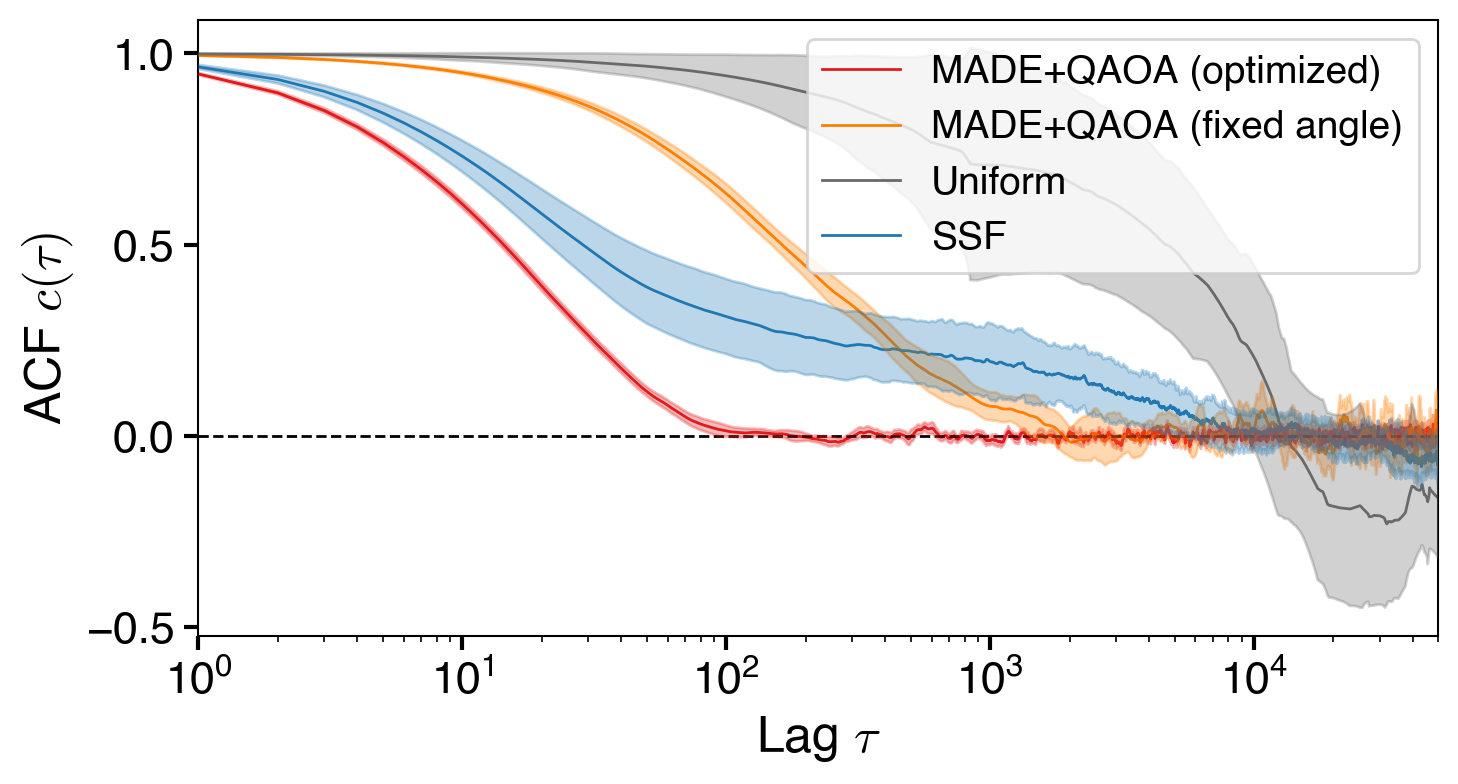

In [9]:
sqrt_mag_acf_opt_made_ave, sqrt_mag_acf_opt_made_std = np.average(mag_acf_history_opt_made, axis=0), np.std(mag_acf_history_opt_made, axis=0)
sqrt_mag_acf_fix_made_ave, sqrt_mag_acf_fix_made_std = np.average(mag_acf_history_fix_made, axis=0), np.std(mag_acf_history_fix_made, axis=0)
sqrt_mag_acf_uni_ave, sqrt_mag_acf_uni_std = np.average(mag_acf_history_uni, axis=0), np.std(mag_acf_history_uni, axis=0)
sqrt_mag_acf_ssf_ave, sqrt_mag_acf_ssf_std = np.average(mag_acf_history_ssf, axis=0), np.std(mag_acf_history_ssf, axis=0)

fig3, ax3 = plt.subplots(figsize=(8,4), dpi=200)

ax3.spines["top"].set_linewidth(spines)
ax3.spines["left"].set_linewidth(spines)
ax3.spines["bottom"].set_linewidth(spines)
ax3.spines["right"].set_linewidth(spines)

ax3.plot(np.arange(lag), sqrt_mag_acf_opt_made_ave, color=red, linewidth=linewidth, label='MADE+QAOA (optimized)')
ax3.fill_between(np.arange(lag), sqrt_mag_acf_opt_made_ave+sqrt_mag_acf_opt_made_std, sqrt_mag_acf_opt_made_ave-sqrt_mag_acf_opt_made_std, color=red, alpha=0.3, zorder=4)
ax3.plot(np.arange(lag), sqrt_mag_acf_fix_made_ave, color=orange, linewidth=linewidth, label='MADE+QAOA (fixed angle)')
ax3.fill_between(np.arange(lag), sqrt_mag_acf_fix_made_ave+sqrt_mag_acf_fix_made_std, sqrt_mag_acf_fix_made_ave-sqrt_mag_acf_fix_made_std, color=orange, alpha=0.3, zorder=4)
ax3.plot(np.arange(lag), sqrt_mag_acf_uni_ave, color='dimgrey', linewidth=linewidth, label='Uniform')
ax3.fill_between(np.arange(lag), sqrt_mag_acf_uni_ave+sqrt_mag_acf_uni_std, sqrt_mag_acf_uni_ave-sqrt_mag_acf_uni_std, color='dimgrey', alpha=0.3, zorder=4)
ax3.plot(np.arange(lag), sqrt_mag_acf_ssf_ave, color=blue, linewidth=linewidth, label='SSF')
ax3.fill_between(np.arange(lag), sqrt_mag_acf_ssf_ave+sqrt_mag_acf_ssf_std, sqrt_mag_acf_ssf_ave-sqrt_mag_acf_ssf_std, color=blue, alpha=0.3, zorder=4)

ax3.axhline(0.0, color='black', linestyle='--', linewidth=linewidth)

ax3.set_xlim(1, lag)
ax3.set_xscale('log')
ax3.set_xlabel(r'Lag $\tau$', fontsize=18)
ax3.set_ylabel(r'ACF $c(\tau)$', fontsize=18)
ax3.tick_params(width=1.5, labelsize=16, length=5, labelbottom=True)
ax3.tick_params(axis="x", which='major', width=1.5)
ax3.legend(fontsize=14, loc='upper right', frameon=True)

In [10]:
def compute_ess(acf):
	negative_idx = np.argmax(acf < 0, axis=1)
	negative_idx[negative_idx==0] = acf.shape[1] - 1
	print(negative_idx)

	ess = []
	for i in range(acf.shape[0]):
		ess_i = np.zeros(negative_idx[i])
		for j in range(negative_idx[i]):
			acf_sum_series = np.sum(acf[i,1:j+1])
			ess_i[j] = 1.0 / (1.0 + 2.0 * acf_sum_series)
		ess.append(ess_i)

	return ess

opt_made_ess = compute_ess(mag_acf_history_opt_made)
fix_made_ess = compute_ess(mag_acf_history_fix_made)
uniform_ess = compute_ess(mag_acf_history_uni)
ssf_ess = compute_ess(mag_acf_history_ssf)

opt_made_ess_mean = np.average(np.array([opt_made_ess[i][-1] for i in range(len(opt_made_ess))]))
fix_made_ess_mean = np.average(np.array([fix_made_ess[i][-1] for i in range(len(fix_made_ess))]))
uniform_ess_mean = np.average(np.array([uniform_ess[i][-1] for i in range(len(uniform_ess))]))
ssf_ess_mean = np.average(np.array([ssf_ess[i][-1] for i in range(len(ssf_ess))]))

[199 214 137  86 155 165  90  90 171 153]
[1932 3933 1802 1389 1276 1792 1777 3585 1647  924]
[16622 13753 31431 14276  8609 10447 15271   840  8200 12193]
[14737  6234  2419  2120  8254 13089 16529  6236  6003  3731]


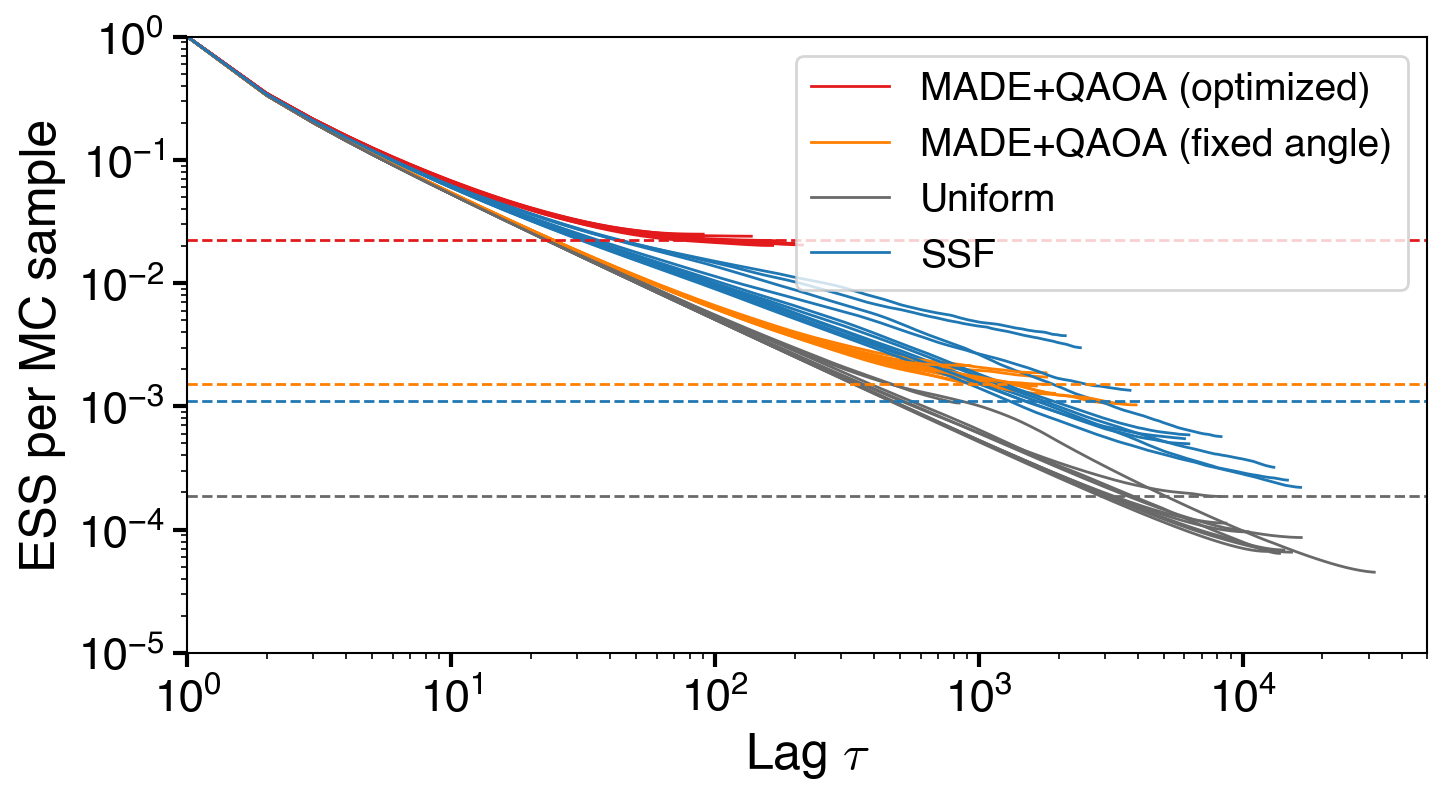

In [11]:
fig4, ax4 = plt.subplots(figsize=(8,4), dpi=200)

ax4.spines["top"].set_linewidth(spines)
ax4.spines["left"].set_linewidth(spines)
ax4.spines["bottom"].set_linewidth(spines)
ax4.spines["right"].set_linewidth(spines)

for i in range(len(opt_made_ess)):
	if i == 0:
		ax4.plot(np.arange(1, opt_made_ess[i].shape[0]+1), opt_made_ess[i], color=red, linewidth=linewidth, label='MADE+QAOA (optimized)')
		ax4.plot(np.arange(1, fix_made_ess[i].shape[0]+1), fix_made_ess[i], color=orange, linewidth=linewidth, label='MADE+QAOA (fixed angle)')
		ax4.plot(np.arange(1, uniform_ess[i].shape[0]+1), uniform_ess[i], color='dimgrey', linewidth=linewidth, label='Uniform')
		ax4.plot(np.arange(1, ssf_ess[i].shape[0]+1), ssf_ess[i], color=blue, linewidth=linewidth, label='SSF')
	else:
		ax4.plot(np.arange(1, opt_made_ess[i].shape[0]+1), opt_made_ess[i], color=red, linewidth=linewidth)
		ax4.plot(np.arange(1, fix_made_ess[i].shape[0]+1), fix_made_ess[i], color=orange, linewidth=linewidth)
		ax4.plot(np.arange(1, uniform_ess[i].shape[0]+1), uniform_ess[i], color='dimgrey', linewidth=linewidth)
		ax4.plot(np.arange(1, ssf_ess[i].shape[0]+1), ssf_ess[i], color=blue, linewidth=linewidth)

ax4.axhline(opt_made_ess_mean, color=red, linestyle='--', linewidth=linewidth)
ax4.axhline(fix_made_ess_mean, color=orange, linestyle='--', linewidth=linewidth)
ax4.axhline(uniform_ess_mean, color='dimgrey', linestyle='--', linewidth=linewidth)
ax4.axhline(ssf_ess_mean, color=blue, linestyle='--', linewidth=linewidth)

ax4.set_xlim(1, lag)
ax4.set_ylim(1e-5, 1)
ax4.set_xscale('log')
ax4.set_yscale('log')
ax4.set_xlabel(r'Lag $\tau$', fontsize=18)
ax4.set_ylabel(r'ESS per MC sample', fontsize=18)
ax4.tick_params(width=1.5, labelsize=16, length=5, labelbottom=True)
ax4.tick_params(axis="x", which='major', width=1.5)
ax4.legend(fontsize=14, loc='upper right', frameon=True)

## Test instance

In [12]:
"""
n_spin = 15

opt_qaoa_made_update_log = np.load('result/mcmc_simulation/{0}_sites_result/update_log/opt_qaoa_made_update_log.npy'.format(n_spin), allow_pickle=True)
fix_qaoa_made_update_log = np.load('result/mcmc_simulation/{0}_sites_result/update_log/fix_qaoa_made_update_log.npy'.format(n_spin), allow_pickle=True)
uniform_update_log = np.load('result/mcmc_simulation/{0}_sites_result/update_log/uniform_update_log.npy'.format(n_spin), allow_pickle=True)
ssf_update_log = np.load('result/mcmc_simulation/{0}_sites_result/update_log/ssf_update_log.npy'.format(n_spin), allow_pickle=True)

opt_accept_rate = np.count_nonzero(opt_qaoa_made_update_log, axis=1) / opt_qaoa_made_update_log.shape[1]
fix_accept_rate = np.count_nonzero(fix_qaoa_made_update_log, axis=1) / fix_qaoa_made_update_log.shape[1]
uni_accept_rate = np.count_nonzero(uniform_update_log, axis=1) / uniform_update_log.shape[1]
ssf_accept_rate = np.count_nonzero(ssf_update_log, axis=1) / ssf_update_log.shape[1]

print(opt_accept_rate)
print(fix_accept_rate)
print(uni_accept_rate)
print(ssf_accept_rate)

opt_qaoa_made_sample = np.load('result/mcmc_simulation/{0}_sites_result/sample/opt_qaoa_made_sample.npy'.format(n_spin), allow_pickle=True)
fix_qaoa_made_sample = np.load('result/mcmc_simulation/{0}_sites_result/sample/fix_qaoa_made_sample.npy'.format(n_spin), allow_pickle=True)
uniform_sample = np.load('result/mcmc_simulation/{0}_sites_result/sample/uniform_sample.npy'.format(n_spin), allow_pickle=True)
ssf_sample = np.load('result/mcmc_simulation/{0}_sites_result/sample/ssf_sample.npy'.format(n_spin), allow_pickle=True)

normalize = np.tile(np.arange(1, opt_qaoa_made_sample.shape[1]+1), (opt_qaoa_made_sample.shape[0], 1))
opt_mag = np.cumsum(np.average(opt_qaoa_made_sample, axis=2), axis=1) / normalize
fix_mag = np.cumsum(np.average(fix_qaoa_made_sample, axis=2), axis=1) / normalize
uniform_mag = np.cumsum(np.average(uniform_sample, axis=2), axis=1) / normalize
ssf_mag = np.cumsum(np.average(ssf_sample, axis=2), axis=1) / normalize

opt_qaoa_made_mag_mean = np.average(opt_mag**2, axis=0)
fix_qaoa_made_mag_mean = np.average(fix_mag**2, axis=0)
uniform_mag_mean = np.average(uniform_mag**2, axis=0)
ssf_mag_mean = np.average(ssf_mag**2, axis=0)

opt_qaoa_made_mag_std = np.std(opt_mag**2, axis=0)
fix_qaoa_made_mag_std = np.std(fix_mag**2, axis=0)
uniform_mag_std = np.std(uniform_mag**2, axis=0)
ssf_mag_std = np.std(ssf_mag**2, axis=0)

n_step = opt_qaoa_made_sample.shape[1] - 1

capsize = 2
markersize = 3
elinewidth = 1
capthick = 1
linewidth = 1
spines = 0.75
fontsize = 8

fig9, ax9 = plt.subplots(figsize=(7.08,2.5), dpi=300)

ax9.spines["top"].set_linewidth(spines)
ax9.spines["left"].set_linewidth(spines)
ax9.spines["bottom"].set_linewidth(spines)
ax9.spines["right"].set_linewidth(spines)

ax9.plot(np.arange(n_step+1), opt_qaoa_made_mag_mean, color=red, linewidth=linewidth, label='MADE+QAOA (optimized)', zorder=5)
ax9.fill_between(np.arange(n_step+1), opt_qaoa_made_mag_mean+opt_qaoa_made_mag_std, opt_qaoa_made_mag_mean-opt_qaoa_made_mag_std, color=red, alpha=0.3, zorder=4)

ax9.plot(np.arange(n_step+1), fix_qaoa_made_mag_mean, color=orange, linewidth=linewidth, label='MADE+QAOA (fixed angle)', zorder=5)
ax9.fill_between(np.arange(n_step+1), fix_qaoa_made_mag_mean+fix_qaoa_made_mag_std, fix_qaoa_made_mag_mean-fix_qaoa_made_mag_std, color=orange, alpha=0.3, zorder=3)

ax9.plot(np.arange(n_step+1), uniform_mag_mean, color='dimgrey', linewidth=linewidth, label='Uniform', zorder=5)
ax9.fill_between(np.arange(n_step+1), uniform_mag_mean+uniform_mag_std, uniform_mag_mean-uniform_mag_std, color='grey', alpha=0.5, zorder=2)

ax9.plot(np.arange(n_step+1), ssf_mag_mean, color=blue, linewidth=linewidth, label='SSF', zorder=5)
ax9.fill_between(np.arange(n_step+1), ssf_mag_mean+ssf_mag_std, ssf_mag_mean-ssf_mag_std, color=blue, alpha=0.25, zorder=1)

ax9.axhline(0.0, color='black', linestyle='--', linewidth=linewidth)
#ax9.axhline(true_val, color='black', linestyle='--', linewidth=linewidth)

ax9.set_xlim(1, n_step)
ax9.set_xscale('log')
ax9.set_yscale('log')
ax9.set_ylim(1e-5,1e-1)
ax9.set_xlabel('MCMC steps', fontsize=fontsize)
ax9.set_ylabel(r'Running average ${|\hat{m}|}^2$', fontsize=fontsize)
ax9.tick_params(width=spines, labelsize=fontsize, length=2.5, labelbottom=True)
ax9.tick_params(axis="x", which='major', width=spines)
"""

'\nn_spin = 15\n\nopt_qaoa_made_update_log = np.load(\'result/mcmc_simulation/{0}_sites_result/update_log/opt_qaoa_made_update_log.npy\'.format(n_spin), allow_pickle=True)\nfix_qaoa_made_update_log = np.load(\'result/mcmc_simulation/{0}_sites_result/update_log/fix_qaoa_made_update_log.npy\'.format(n_spin), allow_pickle=True)\nuniform_update_log = np.load(\'result/mcmc_simulation/{0}_sites_result/update_log/uniform_update_log.npy\'.format(n_spin), allow_pickle=True)\nssf_update_log = np.load(\'result/mcmc_simulation/{0}_sites_result/update_log/ssf_update_log.npy\'.format(n_spin), allow_pickle=True)\n\nopt_accept_rate = np.count_nonzero(opt_qaoa_made_update_log, axis=1) / opt_qaoa_made_update_log.shape[1]\nfix_accept_rate = np.count_nonzero(fix_qaoa_made_update_log, axis=1) / fix_qaoa_made_update_log.shape[1]\nuni_accept_rate = np.count_nonzero(uniform_update_log, axis=1) / uniform_update_log.shape[1]\nssf_accept_rate = np.count_nonzero(ssf_update_log, axis=1) / ssf_update_log.shape[1]\n